# Notebook 05 — Model Evaluation (CBR Pidana Penadahan)

Notebook ini mengimplementasikan **Tahap 5: Model Evaluation** pada pipeline Case-Based Reasoning (CBR) untuk putusan pidana penadahan.

Notebook ini **melanjutkan** Notebook 01–04 yang sudah selesai, dan **hanya membaca file hasil** dari notebook-notebook sebelumnya:
- `data/results/predictions.csv` (Notebook 04)
- `data/eval/retrieval_metrics.csv` (Notebook 03)

Notebook ini **tidak** melakukan:
- training ulang model
- pembuatan TF-IDF ulang
- retrieval ulang (`retrieve()`)
- prediksi ulang (`predict_outcome()`)

Seluruh evaluasi dihitung murni dari kolom `true_label`, `prediction_majority`, dan `prediction_weighted` pada `predictions.csv`.

**Output notebook ini:**
- `data/eval/prediction_metrics.csv`


## Cell 1 — Import Library

Mengimpor seluruh library yang dibutuhkan untuk evaluasi: manipulasi data, visualisasi, dan metrik klasifikasi.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

print("Library berhasil diimpor.")


Library berhasil diimpor.


In [2]:
import os

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

print(os.listdir(BASE_DIR))

['models', 'logs', 'as', 'Data', 'notebooks', 'src']


## Cell 2 — Konfigurasi Path

Menggunakan `BASE_DIR` yang sama seperti Notebook 02–04 (notebook diasumsikan berada di folder `notebooks/`, sehingga `BASE_DIR` diarahkan satu level ke atas, ke root project `CBR_PENADAHAN/`).


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ======================================
# PATH PROJECT
# ======================================

# Jika notebook berada di folder notebooks/
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

PREDICTIONS_PATH = os.path.join(
    BASE_DIR,
    "data",
    "results",
    "predictions.csv"
)

RETRIEVAL_METRICS_PATH = os.path.join(
    BASE_DIR,
    "data",
    "eval",
    "retrieval_metrics.csv"
)

EVAL_DIR = os.path.join(
    BASE_DIR,
    "data",
    "eval"
)

PREDICTION_METRICS_PATH = os.path.join(
    EVAL_DIR,
    "prediction_metrics.csv"
)

os.makedirs(EVAL_DIR, exist_ok=True)

print("========== PROJECT PATH ==========")
print("BASE_DIR                :", BASE_DIR)
print("PREDICTIONS_PATH        :", PREDICTIONS_PATH)
print("RETRIEVAL_METRICS_PATH  :", RETRIEVAL_METRICS_PATH)
print("EVAL_DIR               :", EVAL_DIR)
print("PREDICTION_METRICS_PATH :", PREDICTION_METRICS_PATH)
print("==================================")

========== PROJECT PATH ==========
BASE_DIR                : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN
PREDICTIONS_PATH        : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/results/predictions.csv
RETRIEVAL_METRICS_PATH  : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/eval/retrieval_metrics.csv
EVAL_DIR               : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/eval
PREDICTION_METRICS_PATH : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/eval/prediction_metrics.csv


## Cell 3 — Load predictions.csv

Memuat `predictions.csv` hasil Notebook 04, lalu menampilkan `head()`, `info()`, `shape`, dan `value_counts()` untuk setiap kolom label. Dilakukan juga validasi bahwa kolom `true_label`, `prediction_majority`, dan `prediction_weighted` benar-benar ada.


In [4]:
assert os.path.exists(PREDICTIONS_PATH), f"predictions.csv tidak ditemukan di: {PREDICTIONS_PATH}"

predictions_df = pd.read_csv(PREDICTIONS_PATH)

required_cols = ["true_label", "prediction_majority", "prediction_weighted"]
for col in required_cols:
    assert col in predictions_df.columns, f"Kolom '{col}' tidak ditemukan pada predictions.csv"

print("predictions.csv berhasil dimuat dan kolom wajib tersedia.")
print()
print("Shape:", predictions_df.shape)
print()
print("Head:")
print(predictions_df.head())


predictions.csv berhasil dimuat dan kolom wajib tersedia.

Shape: (5, 6)

Head:
   query_id                                         query_text true_label  \
0         1  menimbang, bahwa terdakwa diajukan kepersidang...     Sedang   
1         2  menimbang, bahwa terdakwa diajukan ke persidan...     Sedang   
2         3  menimbang bahwa putusan pengadilan tinggi jamb...     Ringan   
3         4  menimbang bahwa putusan pengadilan tinggi band...     Sedang   
4         5  menimbang, bahwa terdakwa diajukan ke persidan...      Berat   

  prediction_majority prediction_weighted  \
0              Sedang              Sedang   
1              Sedang              Sedang   
2              Sedang              Sedang   
3              Sedang              Sedang   
4              Ringan              Ringan   

                                 top_5_case_ids  
0  case_014;case_005;case_021;case_026;case_024  
1  case_040;case_044;case_001;case_019;case_032  
2  case_032;case_036;case_031;case_0

In [5]:
print("Info:")
predictions_df.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   query_id             5 non-null      int64 
 1   query_text           5 non-null      object
 2   true_label           5 non-null      object
 3   prediction_majority  5 non-null      object
 4   prediction_weighted  5 non-null      object
 5   top_5_case_ids       5 non-null      object
dtypes: int64(1), object(5)
memory usage: 372.0+ bytes


In [6]:
print("Distribusi true_label:")
print(predictions_df["true_label"].value_counts())
print()
print("Distribusi prediction_majority:")
print(predictions_df["prediction_majority"].value_counts())
print()
print("Distribusi prediction_weighted:")
print(predictions_df["prediction_weighted"].value_counts())


Distribusi true_label:
true_label
Sedang    3
Ringan    1
Berat     1
Name: count, dtype: int64

Distribusi prediction_majority:
prediction_majority
Sedang    4
Ringan    1
Name: count, dtype: int64

Distribusi prediction_weighted:
prediction_weighted
Sedang    4
Ringan    1
Name: count, dtype: int64


## Cell 4 — Evaluasi Majority Vote

Menghitung Accuracy, Precision, Recall, F1-score (rata-rata `weighted` karena label tidak seimbang), `classification_report`, dan `confusion_matrix` untuk hasil `prediction_majority` dibandingkan `true_label`. Seluruh metrik disimpan ke dictionary `metrics_majority`.


In [7]:
y_true = predictions_df["true_label"]
y_pred_majority = predictions_df["prediction_majority"]

label_order = sorted(y_true.unique())

acc_majority = accuracy_score(y_true, y_pred_majority)
prec_majority = precision_score(y_true, y_pred_majority, average="weighted", zero_division=0)
rec_majority = recall_score(y_true, y_pred_majority, average="weighted", zero_division=0)
f1_majority = f1_score(y_true, y_pred_majority, average="weighted", zero_division=0)

cm_majority = confusion_matrix(y_true, y_pred_majority, labels=label_order)

metrics_majority = {
    "model": "Majority Vote",
    "accuracy": acc_majority,
    "precision": prec_majority,
    "recall": rec_majority,
    "f1_score": f1_majority,
    "n_query": len(predictions_df),
}

print("=== Evaluasi Majority Vote ===")
print("Accuracy :", round(acc_majority, 4))
print("Precision:", round(prec_majority, 4))
print("Recall   :", round(rec_majority, 4))
print("F1-score :", round(f1_majority, 4))
print()
print("Classification Report:")
print(classification_report(y_true, y_pred_majority, zero_division=0))
print()
print("Confusion Matrix (urutan label:", label_order, "):")
print(pd.DataFrame(cm_majority, index=label_order, columns=label_order))


=== Evaluasi Majority Vote ===
Accuracy : 0.6
Precision: 0.45
Recall   : 0.6
F1-score : 0.5143

Classification Report:
              precision    recall  f1-score   support

       Berat       0.00      0.00      0.00         1
      Ringan       0.00      0.00      0.00         1
      Sedang       0.75      1.00      0.86         3

    accuracy                           0.60         5
   macro avg       0.25      0.33      0.29         5
weighted avg       0.45      0.60      0.51         5


Confusion Matrix (urutan label: ['Berat', 'Ringan', 'Sedang'] ):
        Berat  Ringan  Sedang
Berat       0       1       0
Ringan      0       0       1
Sedang      0       0       3


## Cell 5 — Evaluasi Weighted Similarity

Menghitung metrik yang sama (Accuracy, Precision, Recall, F1-score, classification report, confusion matrix) untuk hasil `prediction_weighted` dibandingkan `true_label`. Hasilnya disimpan ke dictionary `metrics_weighted`.


In [8]:
y_pred_weighted = predictions_df["prediction_weighted"]

acc_weighted = accuracy_score(y_true, y_pred_weighted)
prec_weighted = precision_score(y_true, y_pred_weighted, average="weighted", zero_division=0)
rec_weighted = recall_score(y_true, y_pred_weighted, average="weighted", zero_division=0)
f1_weighted = f1_score(y_true, y_pred_weighted, average="weighted", zero_division=0)

cm_weighted = confusion_matrix(y_true, y_pred_weighted, labels=label_order)

metrics_weighted = {
    "model": "Weighted Similarity",
    "accuracy": acc_weighted,
    "precision": prec_weighted,
    "recall": rec_weighted,
    "f1_score": f1_weighted,
    "n_query": len(predictions_df),
}

print("=== Evaluasi Weighted Similarity ===")
print("Accuracy :", round(acc_weighted, 4))
print("Precision:", round(prec_weighted, 4))
print("Recall   :", round(rec_weighted, 4))
print("F1-score :", round(f1_weighted, 4))
print()
print("Classification Report:")
print(classification_report(y_true, y_pred_weighted, zero_division=0))
print()
print("Confusion Matrix (urutan label:", label_order, "):")
print(pd.DataFrame(cm_weighted, index=label_order, columns=label_order))


=== Evaluasi Weighted Similarity ===
Accuracy : 0.6
Precision: 0.45
Recall   : 0.6
F1-score : 0.5143

Classification Report:
              precision    recall  f1-score   support

       Berat       0.00      0.00      0.00         1
      Ringan       0.00      0.00      0.00         1
      Sedang       0.75      1.00      0.86         3

    accuracy                           0.60         5
   macro avg       0.25      0.33      0.29         5
weighted avg       0.45      0.60      0.51         5


Confusion Matrix (urutan label: ['Berat', 'Ringan', 'Sedang'] ):
        Berat  Ringan  Sedang
Berat       0       1       0
Ringan      0       0       1
Sedang      0       0       3


## Cell 6 — Perbandingan Model

Menggabungkan hasil Majority Vote dan Weighted Similarity ke dalam satu DataFrame perbandingan: `Model, Accuracy, Precision, Recall, F1-score`.


In [9]:
comparison_df = pd.DataFrame([
    {
        "Model": metrics_majority["model"],
        "Accuracy": metrics_majority["accuracy"],
        "Precision": metrics_majority["precision"],
        "Recall": metrics_majority["recall"],
        "F1-score": metrics_majority["f1_score"],
    },
    {
        "Model": metrics_weighted["model"],
        "Accuracy": metrics_weighted["accuracy"],
        "Precision": metrics_weighted["precision"],
        "Recall": metrics_weighted["recall"],
        "F1-score": metrics_weighted["f1_score"],
    },
])

comparison_df


,Model,Accuracy,Precision,Recall,F1-score
0,Majority Vote,0.6,0.45,0.6,0.514286
1,Weighted Similarity,0.6,0.45,0.6,0.514286


## Cell 7 — Visualisasi Bar Chart

Membuat bar chart yang membandingkan Accuracy, Precision, Recall, dan F1-score antara Majority Vote dan Weighted Similarity menggunakan `matplotlib`.


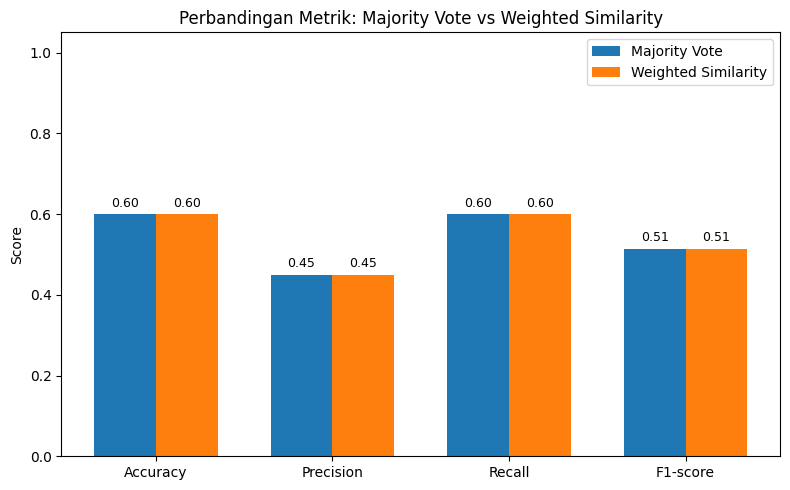

In [10]:
metrics_names = ["Accuracy", "Precision", "Recall", "F1-score"]
majority_values = comparison_df.loc[comparison_df["Model"] == "Majority Vote", metrics_names].values.flatten()
weighted_values = comparison_df.loc[comparison_df["Model"] == "Weighted Similarity", metrics_names].values.flatten()

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bar1 = ax.bar(x - width / 2, majority_values, width, label="Majority Vote")
bar2 = ax.bar(x + width / 2, weighted_values, width, label="Weighted Similarity")

ax.set_ylabel("Score")
ax.set_title("Perbandingan Metrik: Majority Vote vs Weighted Similarity")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.05)
ax.legend()

for bars in [bar1, bar2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()


## Cell 8 — Confusion Matrix (Majority Vote & Weighted Similarity)

Menampilkan confusion matrix untuk Majority Vote dan Weighted Similarity dalam dua figure terpisah menggunakan `ConfusionMatrixDisplay`.


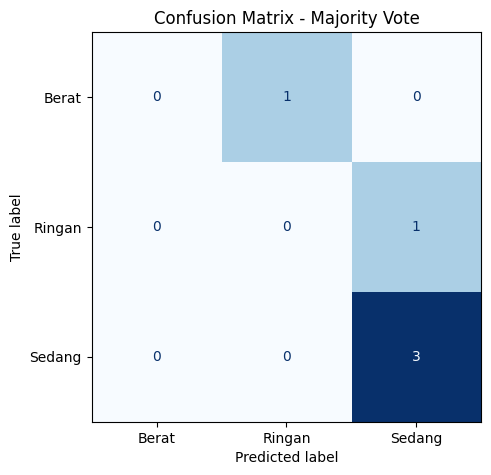

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
disp_majority = ConfusionMatrixDisplay(confusion_matrix=cm_majority, display_labels=label_order)
disp_majority.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix - Majority Vote")
plt.tight_layout()
plt.show()


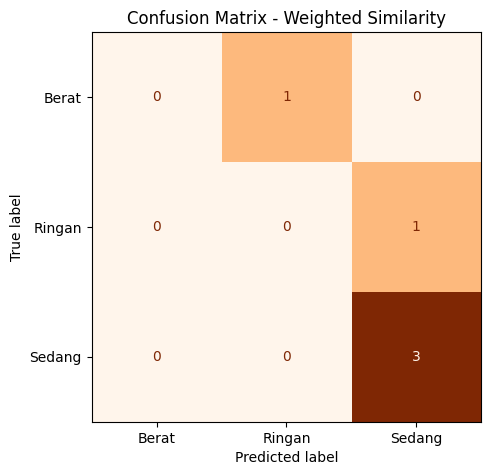

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))
disp_weighted = ConfusionMatrixDisplay(confusion_matrix=cm_weighted, display_labels=label_order)
disp_weighted.plot(ax=ax, cmap="Oranges", colorbar=False)
ax.set_title("Confusion Matrix - Weighted Similarity")
plt.tight_layout()
plt.show()


## Cell 9 — Error Analysis

Membangun DataFrame yang hanya berisi baris dengan prediksi salah (baik pada `prediction_majority` maupun `prediction_weighted`), lalu menghitung jumlah benar, jumlah salah, dan persentase error untuk masing-masing metode.


In [13]:
predictions_df["is_correct_majority"] = predictions_df["true_label"] == predictions_df["prediction_majority"]
predictions_df["is_correct_weighted"] = predictions_df["true_label"] == predictions_df["prediction_weighted"]

# Baris yang salah pada SALAH SATU metode (majority dan/atau weighted)
error_mask = (~predictions_df["is_correct_majority"]) | (~predictions_df["is_correct_weighted"])

error_df = predictions_df.loc[
    error_mask,
    ["query_id", "true_label", "prediction_majority", "prediction_weighted", "query_text"],
].reset_index(drop=True)

print("=== Error Analysis ===")
print(error_df)


=== Error Analysis ===
   query_id true_label prediction_majority prediction_weighted  \
0         3     Ringan              Sedang              Sedang   
1         5      Berat              Ringan              Ringan   

                                          query_text  
0  menimbang bahwa putusan pengadilan tinggi jamb...  
1  menimbang, bahwa terdakwa diajukan ke persidan...  


In [14]:
n_total = len(predictions_df)

n_correct_majority = int(predictions_df["is_correct_majority"].sum())
n_wrong_majority = n_total - n_correct_majority
pct_error_majority = (n_wrong_majority / n_total) * 100

n_correct_weighted = int(predictions_df["is_correct_weighted"].sum())
n_wrong_weighted = n_total - n_correct_weighted
pct_error_weighted = (n_wrong_weighted / n_total) * 100

print("--- Majority Vote ---")
print("Jumlah benar :", n_correct_majority)
print("Jumlah salah :", n_wrong_majority)
print("Persen error :", round(pct_error_majority, 2), "%")
print()
print("--- Weighted Similarity ---")
print("Jumlah benar :", n_correct_weighted)
print("Jumlah salah :", n_wrong_weighted)
print("Persen error :", round(pct_error_weighted, 2), "%")


--- Majority Vote ---
Jumlah benar : 3
Jumlah salah : 2
Persen error : 40.0 %

--- Weighted Similarity ---
Jumlah benar : 3
Jumlah salah : 2
Persen error : 40.0 %


## Cell 10 — Simpan prediction_metrics.csv

Menyimpan metrik evaluasi (Majority Vote dan Weighted Similarity) ke `data/eval/prediction_metrics.csv` dengan kolom: `model, accuracy, precision, recall, f1_score, n_query`.


In [15]:
prediction_metrics_df = pd.DataFrame([metrics_majority, metrics_weighted])
prediction_metrics_df = prediction_metrics_df[["model", "accuracy", "precision", "recall", "f1_score", "n_query"]]

prediction_metrics_df.to_csv(PREDICTION_METRICS_PATH, index=False)

print("prediction_metrics.csv disimpan ke:", PREDICTION_METRICS_PATH)
prediction_metrics_df


prediction_metrics.csv disimpan ke: /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/eval/prediction_metrics.csv


,model,accuracy,precision,recall,f1_score,n_query
0,Majority Vote,0.6,0.45,0.6,0.514286,5
1,Weighted Similarity,0.6,0.45,0.6,0.514286,5


## Cell 11 — Gabungkan dengan retrieval_metrics.csv

Memuat `retrieval_metrics.csv` (hasil Notebook 03) dan menggabungkannya dengan `prediction_metrics.csv` (Cell 10) untuk menampilkan tabel akhir perbandingan: Retrieval, Prediction Majority, dan Prediction Weighted.


In [16]:
assert os.path.exists(RETRIEVAL_METRICS_PATH), f"retrieval_metrics.csv tidak ditemukan di: {RETRIEVAL_METRICS_PATH}"

retrieval_metrics_df = pd.read_csv(RETRIEVAL_METRICS_PATH)

print("Retrieval metrics (Notebook 03):")
print(retrieval_metrics_df)


Retrieval metrics (Notebook 03):
       model  kernel  accuracy  precision  recall  f1_score  n_train  n_test
0  LinearSVC  linear       0.5       0.25     0.5  0.333333       40      10


In [17]:
final_table = pd.DataFrame([
    {
        "Stage": "Retrieval (SVM)",
        "Accuracy": retrieval_metrics_df.loc[0, "accuracy"],
        "Precision": retrieval_metrics_df.loc[0, "precision"],
        "Recall": retrieval_metrics_df.loc[0, "recall"],
        "F1-score": retrieval_metrics_df.loc[0, "f1_score"],
    },
    {
        "Stage": "Prediction - Majority Vote",
        "Accuracy": metrics_majority["accuracy"],
        "Precision": metrics_majority["precision"],
        "Recall": metrics_majority["recall"],
        "F1-score": metrics_majority["f1_score"],
    },
    {
        "Stage": "Prediction - Weighted Similarity",
        "Accuracy": metrics_weighted["accuracy"],
        "Precision": metrics_weighted["precision"],
        "Recall": metrics_weighted["recall"],
        "F1-score": metrics_weighted["f1_score"],
    },
])

print("=== Tabel Akhir: Retrieval vs Prediction ===")
final_table


=== Tabel Akhir: Retrieval vs Prediction ===


,Stage,Accuracy,Precision,Recall,F1-score
0,Retrieval (SVM),0.5,0.25,0.5,0.333333
1,Prediction - Majority Vote,0.6,0.45,0.6,0.514286
2,Prediction - Weighted Similarity,0.6,0.45,0.6,0.514286


## Cell 12 — Kesimpulan

Mencetak ringkasan otomatis: jumlah query, model dengan accuracy terbaik antara Majority Vote dan Weighted Similarity, jumlah prediksi benar/salah, dan persentase error untuk model terbaik tersebut.


In [18]:
best_model_row = comparison_df.loc[comparison_df["Accuracy"].idxmax()]
best_model_name = best_model_row["Model"]
best_model_accuracy = best_model_row["Accuracy"]

if best_model_name == "Majority Vote":
    best_n_correct, best_n_wrong, best_pct_error = n_correct_majority, n_wrong_majority, pct_error_majority
else:
    best_n_correct, best_n_wrong, best_pct_error = n_correct_weighted, n_wrong_weighted, pct_error_weighted

print("========== KESIMPULAN NOTEBOOK 05 ==========")
print(f"Jumlah query yang dievaluasi : {n_total}")
print(f"Model terbaik                : {best_model_name}")
print(f"Accuracy terbaik             : {round(best_model_accuracy, 4)}")
print(f"Jumlah prediksi benar        : {best_n_correct}")
print(f"Jumlah prediksi salah        : {best_n_wrong}")
print(f"Persentase error             : {round(best_pct_error, 2)}%")
print("=============================================")


========== KESIMPULAN NOTEBOOK 05 ==========
Jumlah query yang dievaluasi : 5
Model terbaik                : Majority Vote
Accuracy terbaik             : 0.6
Jumlah prediksi benar        : 3
Jumlah prediksi salah        : 2
Persentase error             : 40.0%


## Ringkasan Notebook 05

- Notebook ini **tidak** melakukan training ulang, pembuatan TF-IDF ulang, retrieval ulang, maupun prediksi ulang — seluruh evaluasi murni dibaca dari `predictions.csv` (Notebook 04) dan `retrieval_metrics.csv` (Notebook 03).
- Path proyek menggunakan `BASE_DIR`, konsisten dengan Notebook 02–04.
- Evaluasi Majority Vote dan Weighted Similarity dihitung lengkap: Accuracy, Precision, Recall, F1-score, Classification Report, dan Confusion Matrix.
- Perbandingan dua metode divisualisasikan dalam bar chart dan confusion matrix terpisah.
- Error analysis menunjukkan baris mana yang diprediksi salah, beserta jumlah benar/salah dan persentase error.
- `data/eval/prediction_metrics.csv` berhasil disimpan dengan kolom `model, accuracy, precision, recall, f1_score, n_query`.
- Tabel akhir menggabungkan hasil Retrieval (Notebook 03) dengan Prediction (Notebook 04) untuk gambaran utuh performa pipeline CBR.
- Kesimpulan otomatis mencetak model terbaik dan ringkasan error.

Notebook ini menyelesaikan **Tahap 5: Model Evaluation** dari pipeline CBR.
